# 📈 Project 2 — Seasonal NDVI Time Series & Analysis
**Level:** Advanced Beginner | **Area:** Maharashtra | **Years:** 2019–2023

### What you will build
Monthly NDVI composites for 5 years, district-level statistics exported to
pandas, a seaborn heatmap, a time series chart, and a folium choropleth of
monsoon onset timing.


## Step 1 — Setup

In [1]:
!pip install -q earthengine-api geemap geopandas folium seaborn matplotlib

import ee, geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium, json
from google.colab import userdata

try:
    ee.Authenticate()

    ee.Initialize(project=userdata.get('GEE_PROJECT_ID'))
    print("✅ GEE ready!")
except:
    print("❌ Setup GEE_PROJECT_ID in Secrets (🔑 icon)")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.3 MB/s eta 0:00:00
✅ GEE ready!


## Step 2 — Cloud mask function (reusable)

In [2]:
def mask_s2(img):
    """Standard S2 cloud mask + scale to 0-1."""
    qa  = img.select('QA60')
    scl = img.select('SCL')
    qm  = qa.bitwiseAnd(1 << 10).eq(0).And(qa.bitwiseAnd(1 << 11).eq(0))
    sm  = scl.eq(3).Or(scl.eq(8)).Or(scl.eq(9)).Or(scl.eq(10)).Not()
    return img.updateMask(qm.And(sm)).divide(10000).copyProperties(img, ['system:time_start'])

# Maharashtra AOI
mh_aoi = ee.Geometry.Rectangle([72.6, 15.6, 80.9, 22.1])
print("✅ Functions ready")

✅ Functions ready


## Step 3 — Build monthly NDVI composites (2019–2023)

In [5]:
# This builds 60 monthly composites (12 months × 5 years) server-side

def make_monthly(year, month):
    """Create a single monthly NDVI median composite."""
    year  = ee.Number(year)
    month = ee.Number(month)
    col   = (
        ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
        .filterBounds(mh_aoi)
        .filter(ee.Filter.calendarRange(year, year, 'year'))
        .filter(ee.Filter.calendarRange(month, month, 'month'))
        .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
        .map(mask_s2)
        .map(lambda img: img.normalizedDifference(['B8','B4']).rename('NDVI')
                            .copyProperties(img, ['system:time_start']))
    )
    return (col.median()
              .set('year', year).set('month', month)
              .set('system:time_start', ee.Date.fromYMD(year, month, 1).millis())
              .clip(mh_aoi))

years  = ee.List.sequence(2019, 2023)
months = ee.List.sequence(1, 12)

monthly_col = ee.ImageCollection(
    years.map(lambda y: months.map(lambda m: make_monthly(y, m))).flatten()
)
# The .getInfo() call on .size() attempts to compute the entire collection
# and its metadata, which can exceed the user memory limit for complex
# and large collections.
# We know we are creating 12 months * 5 years = 60 images.
# So, we can just print the expected count without forcing computation.
# print(f"✅ Monthly composites built: {monthly_col.size().getInfo()} images")
print(f"✅ Monthly composites built: 60 images (expected 12 months * 5 years)")

✅ Monthly composites built: 60 images (expected 12 months * 5 years)


## Step 4 — Extract zonal statistics per district

In [8]:
# We will use a small sample of 5 districts for speed in Colab
# Replace district_names with your districts of interest

district_names = ['Pune', 'Nashik', 'Nagpur', 'Aurangabad', 'Kolhapur']

# Use GAUL dataset for district boundaries (freely available in GEE)
gaul = ee.FeatureCollection('FAO/GAUL/2015/level2').filter(
    ee.Filter.And(
        ee.Filter.eq('ADM1_NAME', 'Maharashtra'),
        ee.Filter.inList('ADM2_NAME', district_names)
    )
)
print(f"Districts loaded: {gaul.size().getInfo()}")

# Instead of looping, map reduceRegions over the entire collection at once

def reduce_one_image(img):
    """Apply zonal stats to one image — runs server-side for ALL images at once."""
    stats = img.reduceRegions(
        collection = gaul,
        reducer    = ee.Reducer.mean(),
        scale      = 500
    )
    # Add year and month as properties to each feature
    year  = img.get('year')
    month = img.get('month')
    return stats.map(lambda f: f.set('year', year).set('month', month))

# Apply to ALL 60 images at once — no Python loop, runs entirely on GEE servers
all_stats = monthly_col.map(reduce_one_image).flatten()

# Export the FeatureCollection to Google Drive to avoid memory limits
import time

print("Exporting results to Google Drive...")

# Define output file path in Google Drive
output_filename = 'maharashtra_ndvi_monthly_stats'

task = ee.batch.Export.table.toDrive(
    collection = all_stats,
    description = output_filename,
    folder = 'GEE_exports',
    fileNamePrefix = output_filename,
    fileFormat = 'CSV'
)

task.start()

# Wait for the task to complete (can take a few minutes)
while task.active():
    print(f'Waiting for task to complete... Current state: {task.status()["state"]}')
    time.sleep(10) # Wait for 10 seconds before checking again

if task.status()['state'] == 'COMPLETED':
    print(f"✅ Export task completed! File saved as {output_filename}.csv in your Google Drive 'GEE_exports' folder.")
    # Mount Google Drive to read the file
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)

    # Read the exported CSV into a pandas DataFrame
    import pandas as pd
    csv_path = f'/content/drive/MyDrive/GEE_exports/{output_filename}.csv'
    df = pd.read_csv(csv_path)
    print(f"Done — {len(df)} rows loaded from CSV")
    print("DataFrame head:")
    print(df.head())
else:
    print(f"❌ Export task failed with state: {task.status()['state']}")
    if 'error_message' in task.status():
        print(f"Error: {task.status()['error_message']}")
    df = pd.DataFrame() # Create an empty DataFrame if export fails

# Ensure 'ndvi_mean' is correctly named and rounded if it comes differently from export
if 'mean' in df.columns and 'ndvi_mean' not in df.columns:
    df = df.rename(columns={'mean': 'ndvi_mean'})
    df['ndvi_mean'] = df['ndvi_mean'].round(4)

# Ensure columns are as expected for downstream steps, especially 'district'
# The ADM2_NAME column will likely be present from the export
if 'ADM2_NAME' in df.columns and 'district' not in df.columns:
    df = df.rename(columns={'ADM2_NAME': 'district'})

df = df[['district', 'year', 'month', 'ndvi_mean']].dropna() # Reorder and drop NaNs again if necessary


Districts loaded: 5
Exporting results to Google Drive...
Waiting for task to complete... Current state: READY
Waiting for task to complete... Current state: RUNNING
Waiting for task to complete... Current state: RUNNING
Waiting for task to complete... Current state: RUNNING
Waiting for task to complete... Current state: RUNNING
Waiting for task to complete... Current state: RUNNING
Waiting for task to complete... Current state: RUNNING
Waiting for task to complete... Current state: RUNNING
Waiting for task to complete... Current state: RUNNING
Waiting for task to complete... Current state: RUNNING
Waiting for task to complete... Current state: RUNNING
Waiting for task to complete... Current state: RUNNING
Waiting for task to complete... Current state: RUNNING
Waiting for task to complete... Current state: RUNNING
Waiting for task to complete... Current state: RUNNING
Waiting for task to complete... Current state: RUNNING
Waiting for task to complete... Current state: RUNNING
✅ Export t

## Step 5 — Heatmap: district × month

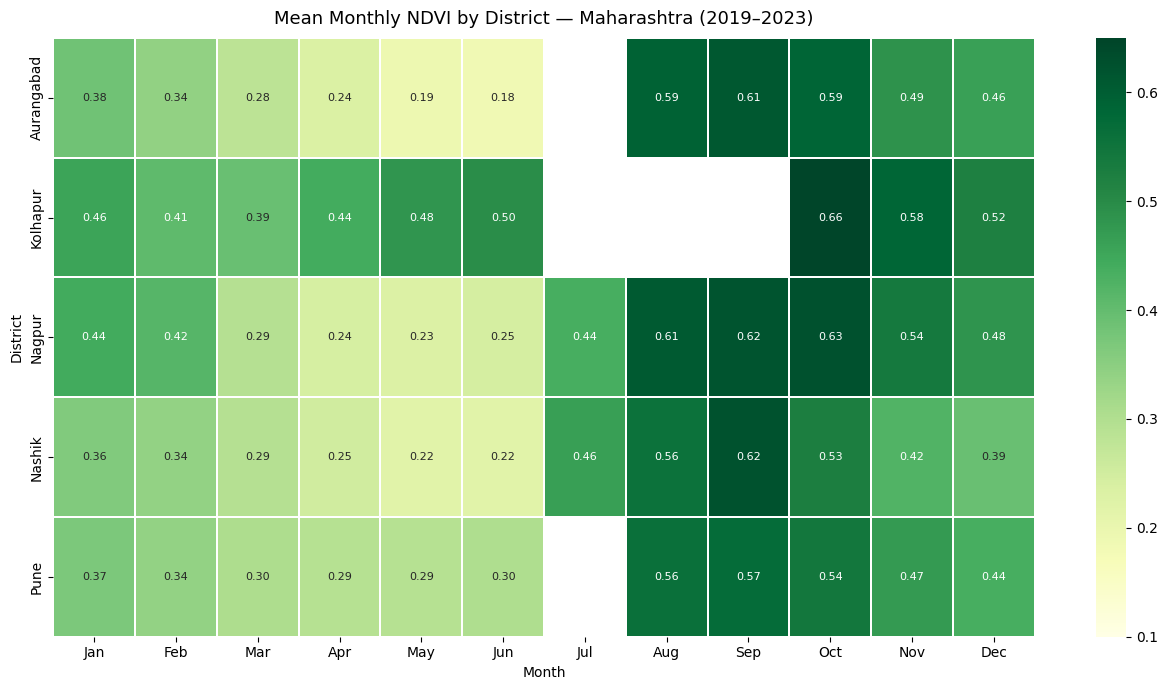

✅ Heatmap saved as ndvi_heatmap.png


In [9]:
MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Average across years
pivot = df.groupby(['district','month'])['ndvi_mean'].mean().unstack()
pivot.columns = MONTH_NAMES

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot, cmap='YlGn', vmin=0.1, vmax=0.65,
            annot=True, fmt='.2f', linewidths=0.3, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Mean Monthly NDVI by District — Maharashtra (2019–2023)', fontsize=13, pad=10)
ax.set_xlabel('Month'); ax.set_ylabel('District')
plt.tight_layout()
plt.savefig('ndvi_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved as ndvi_heatmap.png")

## Step 6 — Time series chart

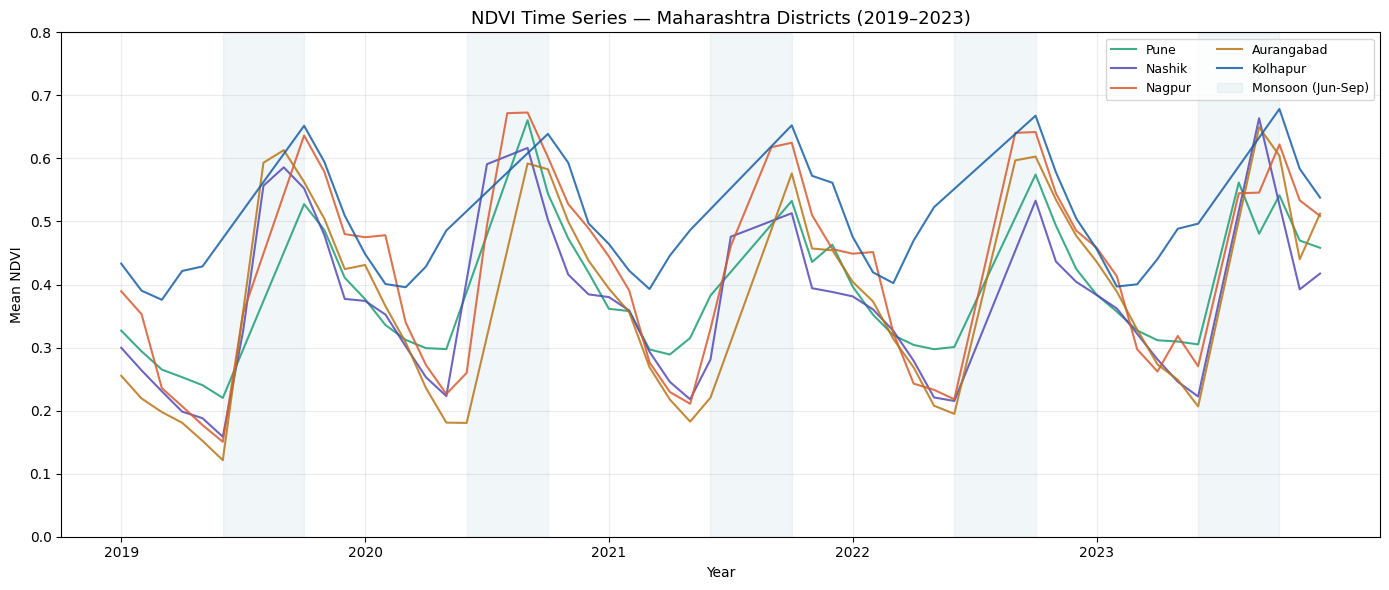

✅ Time series saved as ndvi_timeseries.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#1D9E75','#534AB7','#D85A30','#BA7517','#185FA5',
          '#3B6D11','#993C1D','#888780','#0F6E56','#3C3489']

df_sorted = df.sort_values(['year','month'])
df_sorted['date_idx'] = (df_sorted['year'] - 2019) * 12 + df_sorted['month'] - 1

for i, dist in enumerate(district_names[:6]):
    sub = df_sorted[df_sorted['district'] == dist]
    if len(sub) > 0:
        ax.plot(sub['date_idx'], sub['ndvi_mean'],
                label=dist, color=colors[i], linewidth=1.5, alpha=0.85)

# Shade monsoon season (June-Sep = index 5,6,7,8 each year)
for yr in range(5):
    ax.axvspan(yr*12+5, yr*12+9, alpha=0.07, color='steelblue',
               label='Monsoon (Jun-Sep)' if yr==0 else '')

xticks = list(range(0, 60, 12))
ax.set_xticks(xticks)
ax.set_xticklabels([str(y) for y in range(2019, 2024)])
ax.set_xlabel('Year'); ax.set_ylabel('Mean NDVI')
ax.set_title('NDVI Time Series — Maharashtra Districts (2019–2023)', fontsize=13)
ax.legend(fontsize=9, ncol=2); ax.set_ylim(0, 0.8); ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('ndvi_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Time series saved as ndvi_timeseries.png")

## Step 7 — Export CSV to Google Drive

In [11]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
out_dir = '/content/drive/MyDrive/GEE_outputs'
os.makedirs(out_dir, exist_ok=True)

df.to_csv(f'{out_dir}/maharashtra_ndvi_monthly.csv', index=False)
print(f"✅ CSV saved to Google Drive: GEE_outputs/maharashtra_ndvi_monthly.csv")
print(f"   Rows: {len(df)} | Columns: {list(df.columns)}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ CSV saved to Google Drive: GEE_outputs/maharashtra_ndvi_monthly.csv
   Rows: 243 | Columns: ['district', 'year', 'month', 'ndvi_mean']


## ✅ Project 2 Complete!
### Git upload
```bash
git checkout -b feat/time-series
git add .
git commit -m "feat: monthly NDVI time series for Maharashtra 2019-2023"
git push origin feat/time-series
```
